# Exercise 1: Handwritten Digit Recognition using KNN

Using KNN to identify handwritten digits based on appearance similarity with sample data. The book references the pbharrin/machinelearninginaction repository; we use the equivalent canonical `sklearn.datasets.load_digits()` dataset.

In [1]:
# CH.SC.U4CSE24119 Kavin JS

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import classification_report
import seaborn as sn
import matplotlib.pyplot as plt
import pandas as pd

## Load Digits Dataset

Shape: (1797, 64)
Target names: [0 1 2 3 4 5 6 7 8 9]


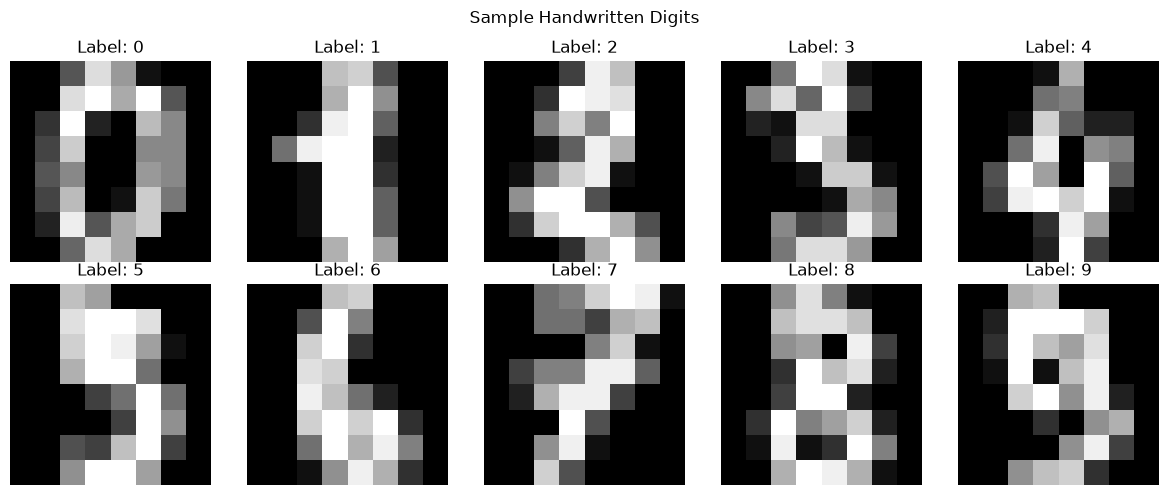

In [2]:
digits = load_digits()
print('Shape:', digits.data.shape)
print('Target names:', digits.target_names)

# Show some sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Sample Handwritten Digits')
plt.tight_layout()
plt.show()

## Split the Data

In [3]:
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.3, random_state=0)

## Train KNN

In [4]:
mdl = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
mdl.fit(x_train, y_train)
y_pred = mdl.predict(x_test)

## Evaluation Metrics

In [5]:
Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')

Accuracy Score :  0.9814814814814815
Accuracy in Percentage :  98 %


## Confusion Matrix Heatmap

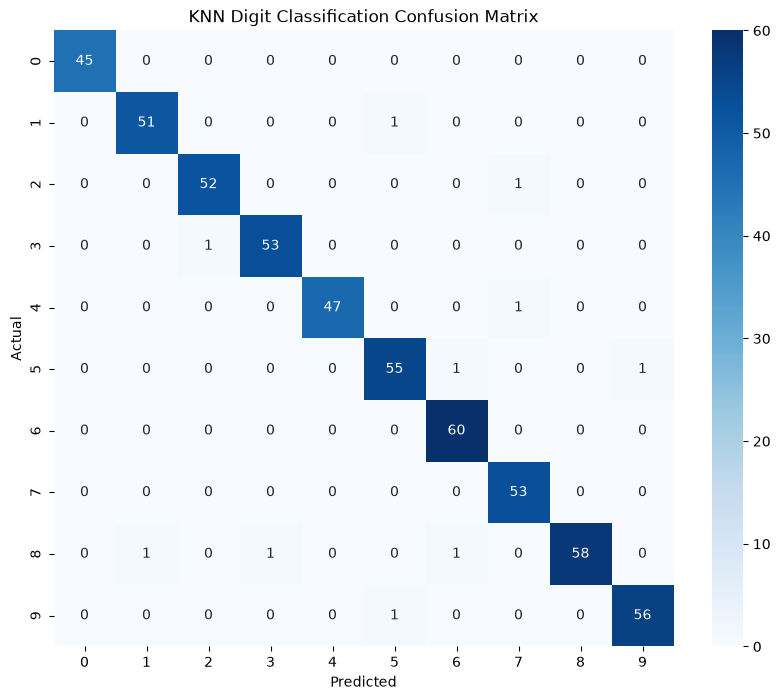

In [6]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
conf_mat_df = pd.DataFrame(conf_mat, index=digits.target_names, columns=digits.target_names)
plt.figure(figsize=(10, 8))
sn.heatmap(conf_mat_df, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Digit Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Classification Report

In [7]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.98      0.98      0.98        52
           2       0.98      0.98      0.98        53
           3       0.98      0.98      0.98        54
           4       0.98      1.00      0.99        47
           5       0.96      0.96      0.96        57
           6       1.00      0.97      0.98        62
           7       1.00      0.96      0.98        55
           8       0.95      1.00      0.97        58
           9       0.98      0.98      0.98        57

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540

